# 04 — Signal Research: Technical Indicators

The screen in notebook 03 answers *what to buy*. The next four notebooks
answer *when to trade*. This one builds the indicator toolkit
(`quantlab.indicators`) and measures whether each indicator carries any
predictive information before we let strategies trade on them.

**Result:** over 2016–2023, Bollinger %B and price/SMA show consistent
*negative* rank correlation with 5-day forward returns (mean-reversion
signal) across a 8-symbol universe; raw momentum is weaker and less stable.
All information coefficients are small (|IC| < 0.1) — normal for daily
equity signals and a warning that costs will matter.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

from quantlab.data import load_prices
from quantlab.indicators import (
    bollinger_bands,
    bollinger_pct_b,
    indicator_frame,
    momentum,
    price_to_sma,
    rolling_volatility,
    sma,
)

plt.rcParams["figure.figsize"] = (11, 5)

SYMBOLS = ["AAPL", "MSFT", "AMZN", "JPM", "JNJ", "XOM", "WMT", "GLD"]
START, END = "2016-01-01", "2023-12-31"
prices = load_prices(SYMBOLS, START, END)

## The indicators, illustrated on one symbol

All implementations are in [`quantlab/indicators/core.py`](../src/quantlab/indicators/core.py)
and unit-tested. Shown on MSFT in 2020 — a year with a crash and a recovery,
which exercises every indicator regime.

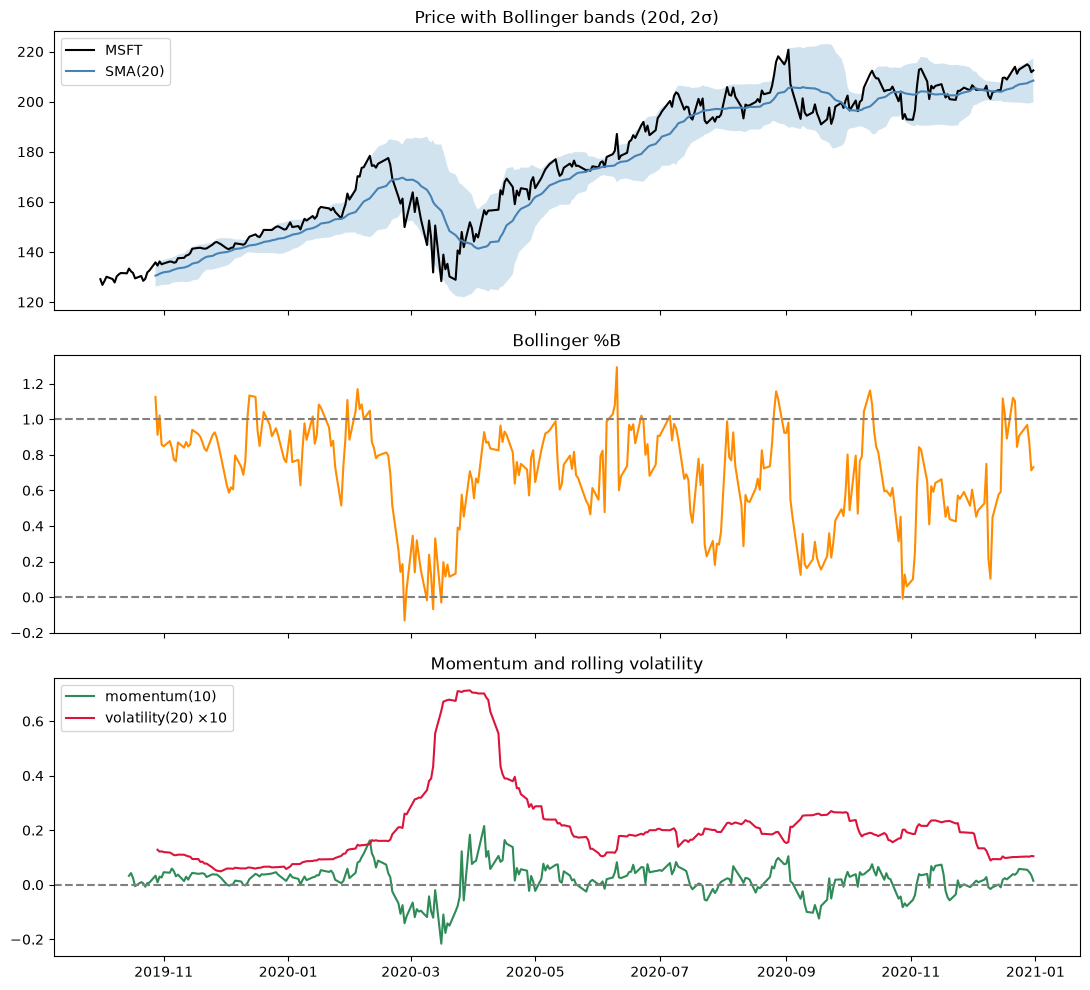

In [2]:
msft = load_prices("MSFT", "2019-10-01", "2020-12-31")["MSFT"]

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

bands = bollinger_bands(msft)
axes[0].plot(msft, label="MSFT", color="black")
axes[0].plot(bands["middle"], label="SMA(20)", color="steelblue")
axes[0].fill_between(bands.index, bands["lower"], bands["upper"], alpha=0.2)
axes[0].legend(loc="upper left")
axes[0].set_title("Price with Bollinger bands (20d, 2σ)")

axes[1].plot(bollinger_pct_b(msft), color="darkorange")
axes[1].axhline(1, ls="--", c="gray")
axes[1].axhline(0, ls="--", c="gray")
axes[1].set_title("Bollinger %B")

axes[2].plot(momentum(msft, 10), color="seagreen", label="momentum(10)")
axes[2].plot(rolling_volatility(msft) * 10, color="crimson", label="volatility(20) ×10")
axes[2].axhline(0, ls="--", c="gray")
axes[2].legend(loc="upper left")
axes[2].set_title("Momentum and rolling volatility")

plt.tight_layout()
plt.savefig("../docs/img/04_indicators_msft.png", dpi=120)
plt.show()

## Do the indicators predict anything?

The standard test is the **information coefficient (IC)**: the Spearman rank
correlation between today's indicator value and the *forward* k-day return.
We compute it per symbol over 2016–2023, with a 5-day horizon.

In [3]:
HORIZON = 5


def information_coefficients(prices: pd.DataFrame, horizon: int = HORIZON) -> pd.DataFrame:
    rows = {}
    for symbol in prices.columns:
        series = prices[symbol]
        features = indicator_frame(series)
        forward = series.shift(-horizon) / series - 1
        ics = {}
        for col in features.columns:
            pair = pd.DataFrame({"f": features[col], "r": forward}).dropna()
            ics[col], _ = stats.spearmanr(pair["f"], pair["r"])
        rows[symbol] = ics
    return pd.DataFrame(rows).T


ic = information_coefficients(prices)
ic.round(4)

,price_to_sma,bb_pct_b,momentum,volatility
AAPL,0.0756,0.0567,0.0776,-0.0337
MSFT,-0.1081,-0.1026,-0.1023,-0.0043
AMZN,-0.0575,-0.0383,-0.0627,-0.0038
JPM,-0.0695,-0.0702,-0.0518,0.0431
JNJ,-0.0165,-0.0174,-0.0432,0.0062
XOM,0.0401,0.0199,0.0253,0.0907
WMT,-0.0465,-0.0339,-0.0281,-0.0096
GLD,-0.0137,-0.0142,-0.0067,0.0005


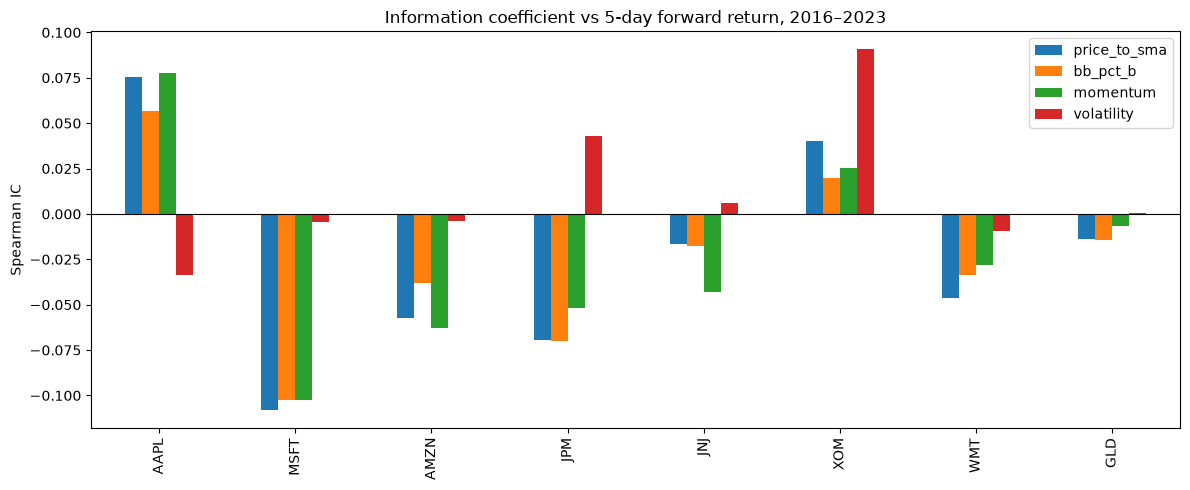

In [4]:
ax = ic.plot.bar(figsize=(12, 5))
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"Information coefficient vs {HORIZON}-day forward return, 2016–2023")
ax.set_ylabel("Spearman IC")
plt.tight_layout()
plt.savefig("../docs/img/04_information_coefficients.png", dpi=120)
plt.show()

In [5]:
summary = ic.agg(["mean", "std"]).T
summary["consistent_sign"] = (ic.apply(lambda col: (col > 0).all() or (col < 0).all()))
summary.round(4)

,mean,std,consistent_sign
price_to_sma,-0.0245,0.0597,False
bb_pct_b,-0.0250,0.0495,False
momentum,-0.0240,0.0558,False
volatility,0.0111,0.0385,False


## Takeaways

- **%B and price/SMA are consistently negative-IC**: stretched prices tend
  to revert over the next week. That motivates the mean-reversion tilt of
  the manual strategy in notebook 06.
- **The edge is tiny.** ICs of a few percent only become tradable when
  aggregated across many decisions and when transaction costs are modeled
  honestly — which is why the backtester (notebook 06) charges commission
  and market impact on every fill.
- Indicators are computed strictly from *past* prices (rolling windows,
  no centered windows), so nothing here leaks future information.

Indicator definitions here feed manual and ML strategies later. A *theoretically optimal* lookahead policy (notebook 06 / research report) shows how large an edge would need to be before costs to matter at all.
